## Parallel Workflow

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
# define state
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    ball_per_boundary: float
    boundary_percentage: float
    summary: str

In [15]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    balls = state["balls"]
    strike_rate = (runs / balls) * 100 if balls > 0 else 0
    return {"strike_rate": round(strike_rate, 2)} # partial update in parallel workflow otherwise will get error

In [16]:
def calculate_ball_per_boundary(state: BatsmanState) -> BatsmanState:
    fours = state["fours"]
    sixes = state["sixes"]
    balls = state["balls"]
    total_boundaries = fours + sixes
    ball_per_boundary = (balls / total_boundaries) if total_boundaries > 0 else float('inf')
    return {"ball_per_boundary": round(ball_per_boundary, 2)}

In [17]:
def calculate_boundary_percentage(state: BatsmanState) -> BatsmanState:
    fours = state["fours"]
    sixes = state["sixes"]
    runs = state["runs"]
    total_boundaries = fours*4 + sixes*6
    boundary_percentage = (total_boundaries / runs) * 100 if runs > 0 else 0
    return {"boundary_percentage": round(boundary_percentage, 2)}

In [18]:
def summary(state: BatsmanState) -> BatsmanState:
    summary = (f"Runs: {state['runs']}, Balls: {state['balls']}, "
                        f"Fours: {state['fours']}, Sixes: {state['sixes']}, "
                        f"Strike Rate: {state['strike_rate']}%, "
                        f"Ball per Boundary: {state['ball_per_boundary']}, "
                        f"Boundary Percentage: {state['boundary_percentage']}%")
    return {"summary": summary}

In [19]:
graph = StateGraph(BatsmanState)

# add nodes
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_ball_per_boundary", calculate_ball_per_boundary)
graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)
graph.add_node("summary", summary)

# add edges
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_ball_per_boundary")
graph.add_edge(START, "calculate_boundary_percentage")

graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_ball_per_boundary", "summary")    
graph.add_edge("calculate_boundary_percentage", "summary")  

graph.add_edge("summary", END)

workflow = graph.compile()

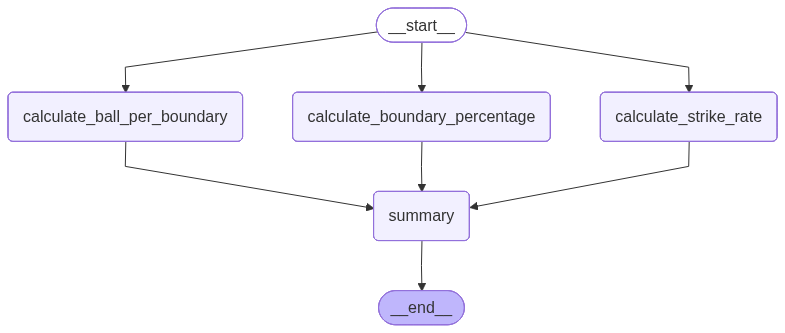

In [20]:
graph.compile()

In [21]:
initial_state = {"runs": 105, "balls": 60, "fours": 11, "sixes": 3}
final_state = workflow.invoke(initial_state)
print(final_state["summary"])

Runs: 105, Balls: 60, Fours: 11, Sixes: 3, Strike Rate: 175.0%, Ball per Boundary: 4.29, Boundary Percentage: 59.05%


In [22]:
workflow.invoke(initial_state)

{'runs': 105,
 'balls': 60,
 'fours': 11,
 'sixes': 3,
 'strike_rate': 175.0,
 'ball_per_boundary': 4.29,
 'boundary_percentage': 59.05,
 'summary': 'Runs: 105, Balls: 60, Fours: 11, Sixes: 3, Strike Rate: 175.0%, Ball per Boundary: 4.29, Boundary Percentage: 59.05%'}